In [10]:
# Task 1: Required Libraries Import & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizations Style Setup
sns.set_theme(style="whitegrid")

# 1. Dataset Loading
df = pd.read_csv('superstore.csv', encoding='latin1')

# 2. Basic Dataset Overview
print("=== DATASET OVERVIEW ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("=== FIRST 5 ROWS ===")
display(df.head())

print("=== DATA TYPES & INFO ===")
print(df.info())

print("=== STATISTICAL SUMMARY ===")
display(df.describe())

=== DATASET OVERVIEW ===
Total Rows: 10800
Total Columns: 21

=== FIRST 5 ROWS ===


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


=== DATA TYPES & INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
# Task 2: Data Cleaning & Pre-processing

# 1. Null rows removing
df_clean = df.dropna(subset=['Order Date']).copy()

# 2. Duplicate rows check & remove
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed successfully!")

# 3. Date columns converting to DateTime format
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'])

# 4. New Derived Columns Creation
df_clean['Order Year'] = df_clean['Order Date'].dt.year
df_clean['Order Month'] = df_clean['Order Date'].dt.month_name()
df_clean['Shipping Days'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days

# 5. Clean dataset details checking
print("\n=== DATA CLEANING COMPLETED ===")
print(f"Cleaned Dataset Shape: {df_clean.shape}")
print("\nNew Derived Columns Data Types:")
print(df_clean[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Shipping Days']].dtypes)

display(df_clean.head(3))

Duplicate rows found: 0

=== DATA CLEANING COMPLETED ===
Cleaned Dataset Shape: (9994, 24)

New Derived Columns Data Types:
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Order Year                int32
Order Month              object
Shipping Days             int64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.9136,2017,November,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.0,219.5820,2017,November,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.8714,2017,June,4


In [12]:
# Cleaned CSV file export
df_clean.to_csv('cleaned_superstore.csv', index=False)
from google.colab import files
files.download('cleaned_superstore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== Category vs Region Pivot Table (Total Sales & Profit) ===


Profit                                            Sales  \
Region              Central        East       South        West      Central   
Category                                                                       
Furniture        -2871.0494   3046.1658   6771.2061  11504.9503  163797.1638   
Office Supplies   8879.9799  41014.5791  19986.3928  52609.8490  167026.4150   
Technology       33697.4320  47462.0351  19991.8314  44303.6496  170416.3120   

                                                      
Region                 East       South         West  
Category                                              
Furniture        208291.204  117298.684  252612.7435  
Office Supplies  205516.055  125651.313  220853.2490  
Technology       264973.981  148771.908  251991.8320

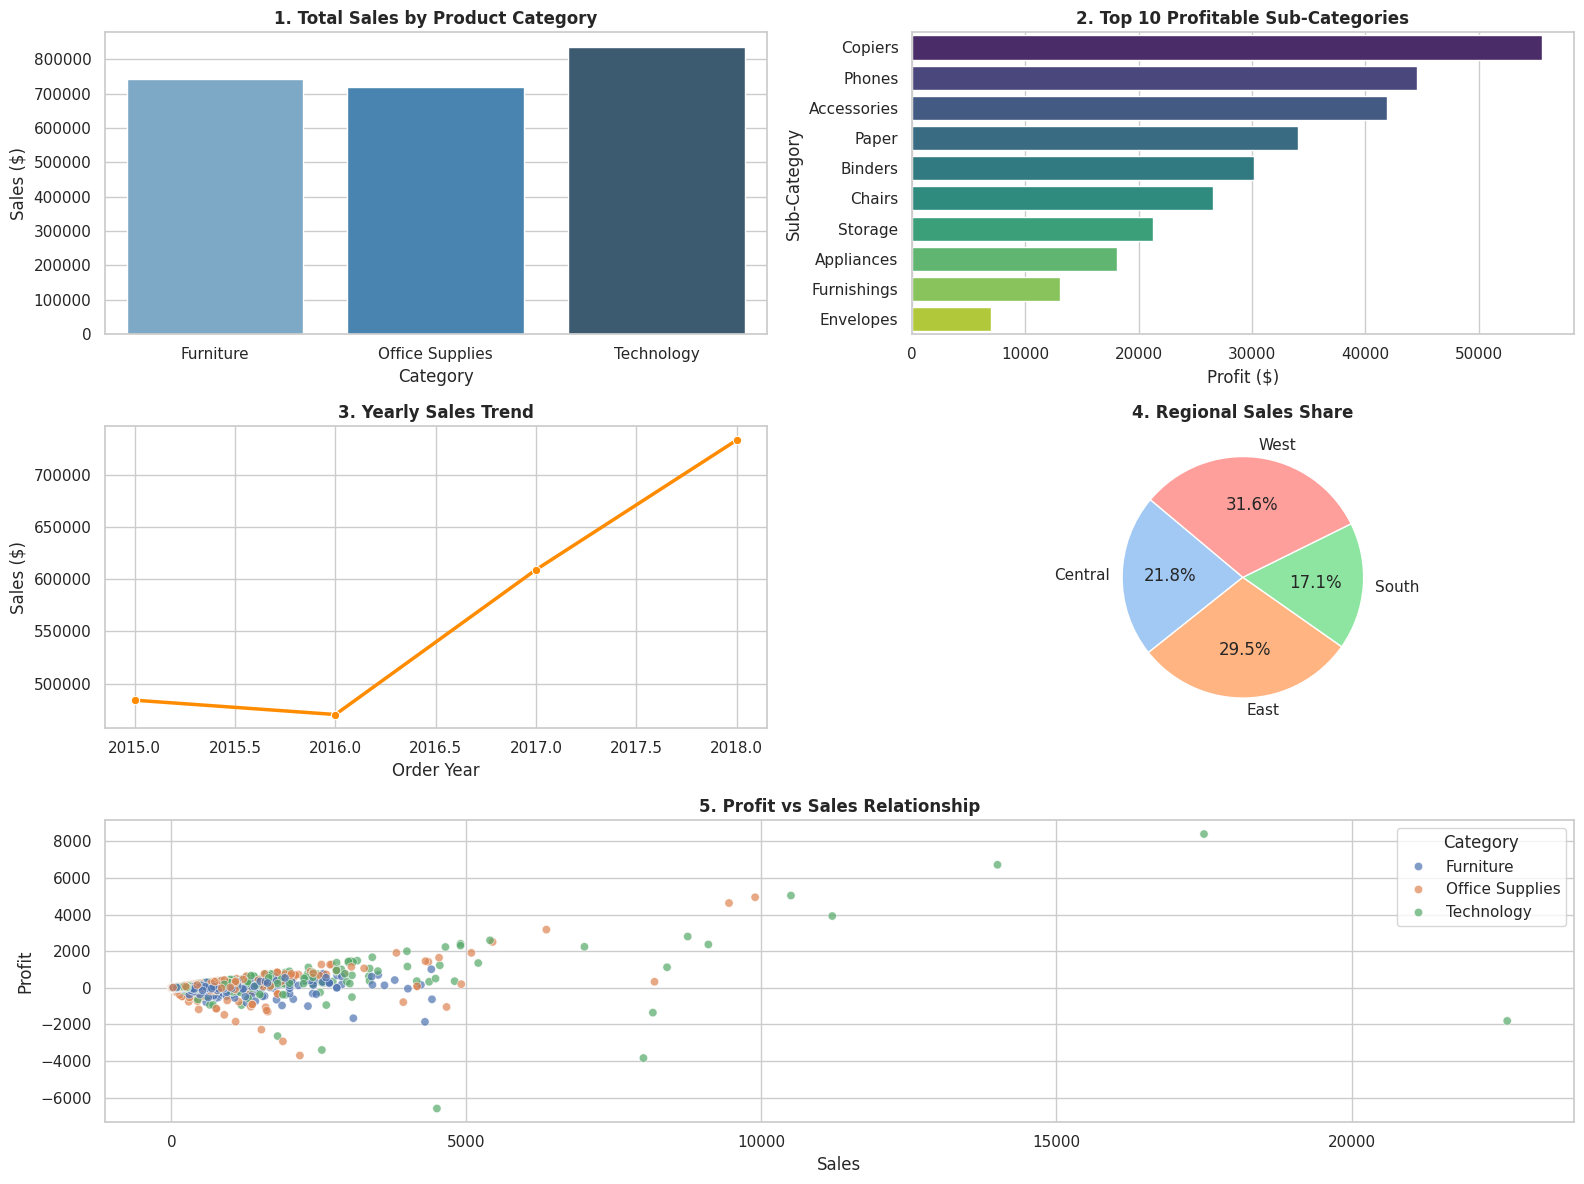

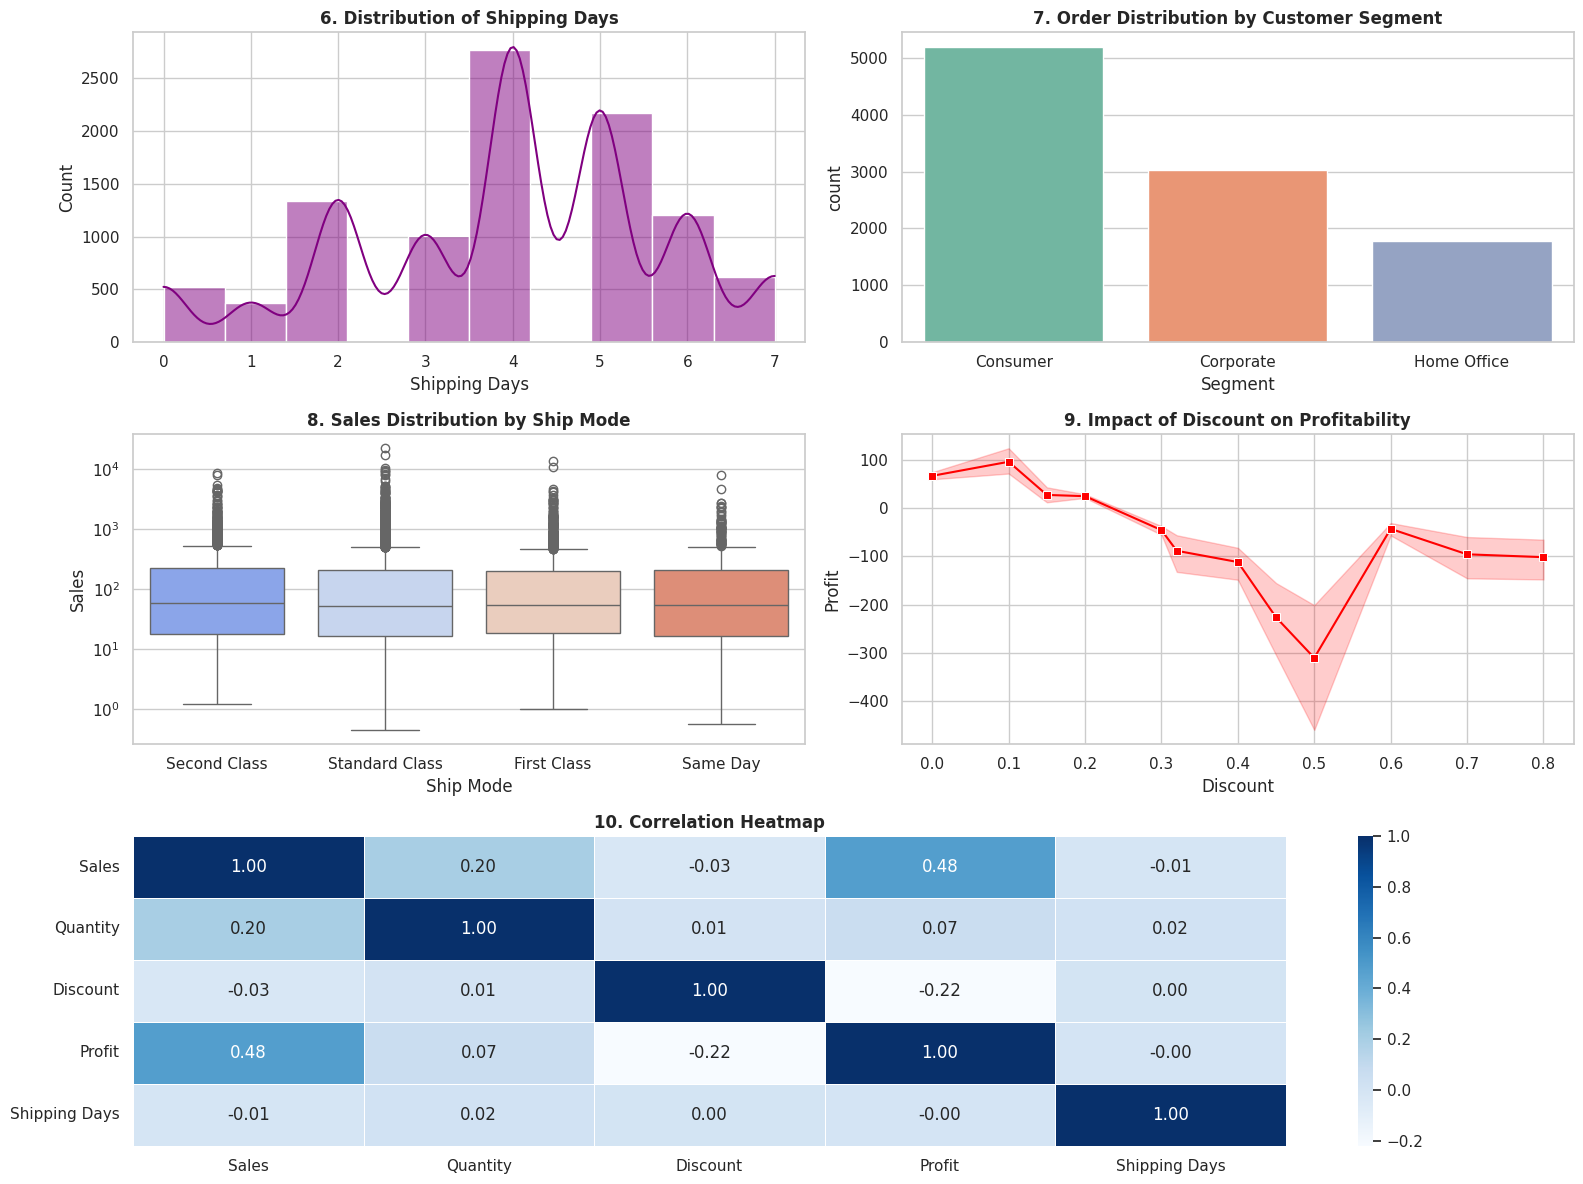

In [13]:
# Task 3: Exploratory Data Analysis (EDA) & Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. Pivot Table Summary (Category vs Region)
# ---------------------------------------------------------
print("=== Category vs Region Pivot Table (Total Sales & Profit) ===")
pivot_summary = pd.pivot_table(
    df_clean,
    values=['Sales', 'Profit'],
    index='Category',
    columns='Region',
    aggfunc='sum'
)
display(pivot_summary)
print("\n" + "="*60 + "\n")

# ---------------------------------------------------------
# 2. Part 1: Visualizations (Charts 1 to 5)
# ---------------------------------------------------------
plt.figure(figsize=(16, 12))

# Chart 1: Total Sales by Product Category
plt.subplot(3, 2, 1)
sns.barplot(data=df_clean, x='Category', y='Sales', hue='Category', estimator=sum, errorbar=None, palette='Blues_d', legend=False)
plt.title('1. Total Sales by Product Category', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)')

# Chart 2: Top 10 Profitable Sub-Categories
plt.subplot(3, 2, 2)
top_subcat = df_clean.groupby('Sub-Category')['Profit'].sum().nlargest(10).reset_index()
sns.barplot(data=top_subcat, y='Sub-Category', x='Profit', hue='Sub-Category', palette='viridis', legend=False)
plt.title('2. Top 10 Profitable Sub-Categories', fontsize=12, fontweight='bold')
plt.xlabel('Profit ($)')

# Chart 3: Yearly Sales Trend
plt.subplot(3, 2, 3)
yearly_sales = df_clean.groupby('Order Year')['Sales'].sum().reset_index()
sns.lineplot(data=yearly_sales, x='Order Year', y='Sales', marker='o', color='darkorange', linewidth=2.5)
plt.title('3. Yearly Sales Trend', fontsize=12, fontweight='bold')
plt.ylabel('Sales ($)')

# Chart 4: Regional Sales Share
plt.subplot(3, 2, 4)
region_sales = df_clean.groupby('Region')['Sales'].sum()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('4. Regional Sales Share', fontsize=12, fontweight='bold')

# Chart 5: Profit vs Sales Relationship
plt.subplot(3, 2, (5, 6))
sns.scatterplot(data=df_clean, x='Sales', y='Profit', hue='Category', alpha=0.7)
plt.title('5. Profit vs Sales Relationship', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Part 2: Visualizations (Charts 6 to 10)
# ---------------------------------------------------------
plt.figure(figsize=(16, 12))

# Chart 6: Shipping Days Distribution
plt.subplot(3, 2, 1)
sns.histplot(df_clean['Shipping Days'], bins=10, kde=True, color='purple')
plt.title('6. Distribution of Shipping Days', fontsize=12, fontweight='bold')
plt.xlabel('Shipping Days')

# Chart 7: Customer Segment Share
plt.subplot(3, 2, 2)
sns.countplot(data=df_clean, x='Segment', hue='Segment', palette='Set2', legend=False)
plt.title('7. Order Distribution by Customer Segment', fontsize=12, fontweight='bold')

# Chart 8: Sales Distribution by Ship Mode
plt.subplot(3, 2, 3)
sns.boxplot(data=df_clean, x='Ship Mode', y='Sales', hue='Ship Mode', palette='coolwarm', legend=False)
plt.title('8. Sales Distribution by Ship Mode', fontsize=12, fontweight='bold')
plt.yscale('log')

# Chart 9: Discount vs Profit Impact
plt.subplot(3, 2, 4)
sns.lineplot(data=df_clean, x='Discount', y='Profit', color='red', marker='s')
plt.title('9. Impact of Discount on Profitability', fontsize=12, fontweight='bold')

# Chart 10: Numerical Features Correlation Heatmap
plt.subplot(3, 2, (5, 6))
corr = df_clean[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('10. Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Task 4: Final Project Insights & Executive Summary

## 1. Executive Summary
This project presents an end-to-end Exploratory Data Analysis (EDA) on the Superstore Sales Dataset. Through structured data cleaning, feature engineering, statistical summaries, and 10 detailed visualizations, key patterns influencing overall sales, profitability, and customer behavior were identified.

---

## 2. Key Business Insights

### Insight 1: Technology Category Drives Highest Revenue & Profit
- **Observation:** The Technology category generates the highest sales revenue and profitability compared to Office Supplies and Furniture.
- **Business Impact:** Technology items (e.g., Copiers and Phones) represent the core value driver for business growth.

### Insight 2: High Discounts Severely Impair Profit Margins
- **Observation:** As shown in Chart 9, offering discounts above 20% leads to a steep decline in profitability, causing negative profit margins.
- **Business Impact:** Uncontrolled discount strategy is the primary cause for transaction losses.

### Insight 3: Loss-Making Sub-Categories
- **Observation:** While sub-categories like Copiers and Phones yield high profit, items such as Tables and Bookcases frequently generate substantial net losses.
- **Business Impact:** High sales volumes in these specific sub-categories do not translate to positive financial returns.

### Insight 4: Regional Market Dominance
- **Observation:** The West region leads in total sales contribution (31.6%), followed closely by the East region (29.5%). Central and South regions present further growth potential.
- **Business Impact:** Regional resource allocation should focus heavily on sustaining West/East momentum while optimizing operations in South/Central areas.

### Insight 5: Operational Shipping Efficiency
- **Observation:** Most customer orders are delivered within 3 to 6 days. Standard Class remains the most preferred shipping mode across all customer segments (Consumer, Corporate, and Home Office).
- **Business Impact:** Logistics operations are stable, but shipping speed can be strategically leveraged for premium services.

---

## 3. Strategic Recommendations & Next Steps

1. **Optimize Discount Structure:** Implement a strict cap on maximum allowed discounts (under 20%) to prevent loss-making sales.
2. **Product Strategy:** Re-evaluate pricing and supply chain costs for low-margin/loss-making sub-categories like Tables and Bookcases.
3. **Cross-Selling Opportunities:** Target Consumer segments in the West region with bundled Technology products to maximize average basket value.